In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

c:\ProgramData\anaconda3\envs\tf-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Preview the data

                                                 text  label
0   Wall St. Bears Claw Back Into the Black (Reute...      2
1   Carlyle Looks Toward Commercial Aerospace (Reu...      2
2   Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3   Iraq Halts Oil Exports from Main Southern Pipe...      2
4   Oil prices soar to all-time record, posing new...      2
..                                                ...    ...
95  Gene Blocker Turns Monkeys Into Workaholics - ...      3
96  Dolphins Too Have Born Socialites (Reuters) Re...      3
97  What's in a Name? Well, Matt Is Sexier Than Pa...      3
98  UK Scientists Allowed to Clone Human Embryos (...      3
99  Russian Alien Spaceship Claims Raise Eyebrows,...      3

[100 rows x 2 columns]


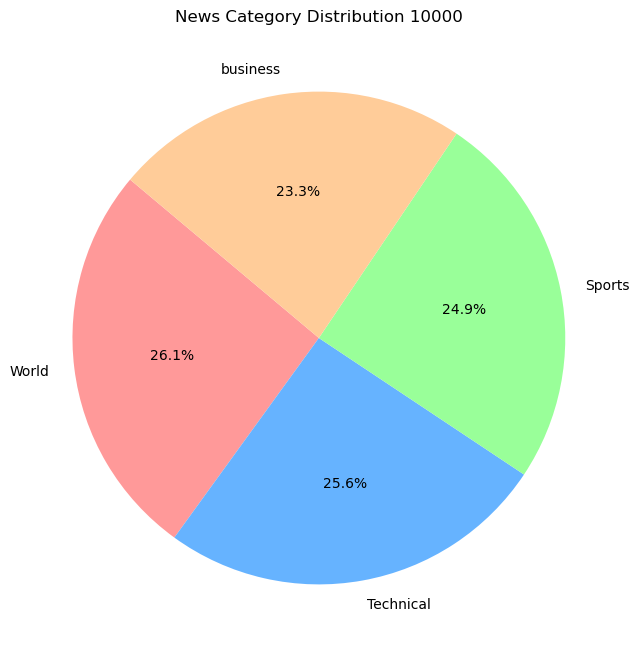

In [2]:
stream_for_preview = load_dataset("ag_news", split="train", streaming=True)
predataset = []
for pre in stream_for_preview.take(20000):
    predataset.append({
        'text': pre['text'],
        'label': pre['label']
    })
dataFrame_predataset = pd.DataFrame(predataset)
print(dataFrame_predataset.head(100))

label_map = {0: "World", 1: "Sports", 2:"business", 3:"Technical"}
dataFrame_predataset['label_name'] = dataFrame_predataset['label'].map(label_map)
category_counts = dataFrame_predataset['label_name'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
plt.title(f'News Category Distribution 10000')
plt.show()


#### normalizer for the length of text

In [3]:
normalize_layer = tf.keras.layers.Normalization(axis=None)
stream_for_normalizer = load_dataset("ag_news", split="train", streaming=True)
sample_lengths = []
for i in stream_for_normalizer.take(20000):
    length = len(i['text'].split())
    sample_lengths.append(length)
normalize_layer.adapt(np.array(sample_lengths))

print(normalize_layer.mean)
print(normalize_layer.variance)

tf.Tensor([38.47497], shape=(1,), dtype=float32)
tf.Tensor([128.89105], shape=(1,), dtype=float32)


#### Vectorize

In [4]:
MAX_VOCABULARY_SIZE = 20000
SEQUENCE_LENGTH = 300
vectorize_layer = layers.TextVectorization(
    max_tokens = MAX_VOCABULARY_SIZE,
    output_sequence_length = SEQUENCE_LENGTH,
    output_mode = "int",
)

stream_for_vectorize = load_dataset("ag_news", split="train", streaming=True)
text_list = []
for i in stream_for_vectorize.take(20000):
    text_list.append(i['text'])
vectorize_layer.adapt(text_list)

test_vectorize = "Nvidia releases new AI chip."
print(vectorize_layer([test_vectorize]).numpy())

[[6381 1976   16 6974  511    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0   

#### Build the tube of data

In [5]:
def data_generator(split_name):
    hf_stream = load_dataset("ag_news", split=split_name, streaming=True)

    for i in hf_stream:
        text = i['text']
        label = i['label']
        length = float(len(text.split()))
        yield ((text, length), label)

# TF need strong typed data, but python is a weak typed langrage
# So we need to define the type of data for TF
output_signature = (
    (
    tf.TensorSpec(shape=(), dtype=tf.string),
    tf.TensorSpec(shape=(), dtype=tf.float32),
    ),
    tf.TensorSpec(shape=(), dtype=tf.int32)
)
train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator("train"),
    output_signature=output_signature
)

BATCH_SIZE = 128
train_ds = train_ds.shuffle(buffer_size=10000)
# prefetch is the key of streamming
# When GPU running the 1st batch of data, CPU already prepared the 2nd batch of data...
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: data_generator("test"),
    output_signature=output_signature
)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# small example
print("\n--- 数据管道预览 (Taking 1 Batch) ---")

# 1. 从管道里接一个 Batch (注意：因为你batch了128，所以这是一“杯”包含128条数据的水)
for inputs, targets in train_ds.take(1):
    # inputs 是一个元组: (text_batch, length_batch)
    text_batch, length_batch = inputs
    label_batch = targets
    
    # 2. 打印形状 (检查 Batch 是否生效)
    print(f"Text Batch Shape:   {text_batch.shape}")   # 应该是 (128,)
    print(f"Length Batch Shape: {length_batch.shape}") # 应该是 (128,)
    print(f"Label Batch Shape:  {label_batch.shape}")  # 应该是 (128,)
    
    # 3. 打印第一条具体数据看看样子 (解码 tensor)
    print("\n--- 第一条数据样本 ---")
    print(f"Text:   {text_batch[0].numpy().decode('utf-8')[:100]}...") # 只打印前100字符
    print(f"Length: {length_batch[0].numpy()}")
    print(f"Label:  {label_batch[0].numpy()}")



--- 数据管道预览 (Taking 1 Batch) ---
Text Batch Shape:   (128,)
Length Batch Shape: (128,)
Label Batch Shape:  (128,)

--- 第一条数据样本 ---
Text:   Hungarian fencing referee suspended for two years A Hungarian fencing referee was expelled from the ...
Length: 37.0
Label:  1


In [6]:
EMBEDDING_DIM = 128
NUM_CLASSES = 4

def build_model(input_normalize_layer, input_vectorlize_layer):
    text_input = keras.Input(shape=(), dtype=tf.string, name="text_input")
    x = input_vectorlize_layer(text_input)
    x = layers.Embedding(MAX_VOCABULARY_SIZE, EMBEDDING_DIM)(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    len_input = keras.Input(shape=(1,), dtype=tf.float32, name="length_input")
    y = input_normalize_layer(len_input)
    y = layers.Dense(16, activation="relu")(y)

    combined = layers.concatenate([x,y])

    z = layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(combined)
    z = layers.Dropout(0.5)(z)
    output = layers.Dense(NUM_CLASSES, activation="softmax")(z)

    model = keras.Model(inputs=[text_input,len_input], outputs=output)
    return model
    
    

In [ ]:
model = build_model(normalize_layer, vectorize_layer)

LEARNING_RATE = 1e-3
model.compile(
    # sparse: Sparse Encoding, different with one-hot, different nums(123) -> different label
    # categorical: more than binary
    # crossentory: the confidence level
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"],
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None,)]            0           []                               
                                                                                                  
 text_vectorization (TextVector  (None, 300)         0           ['text_input[0][0]']             
 ization)                                                                                         
                                                                                                  
 embedding (Embedding)          (None, 300, 128)     2560000     ['text_vectorization[0][0]']     
                                                                                                  
 conv1d (Conv1D)                (None, 300, 128)     82048       ['embedding[0][0]']          

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.001,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 50
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
    938/Unknown - 55s 42ms/step - loss: 0.4360 - accuracy: 0.8442